A new notebook that references the previous notebook, `10.32604-cmc.2022.028801.ipynb`, which is quite large, and I want to separate the manual implementation from this approach, which will use deep learning. 

In [16]:
# !/usr/bin/env python3

# TODO: Compute dataset to preceive optical flow and store into .npy file
# TODO: Create a mark if the frame was already processed
#       If the frame was already processed, skip it

CURRENT_IDENTIFIER = "10.32604-cmc.2022.028801"

In [17]:
import cv2
import numpy as np


class TVL1OpticalFlow:
    def __init__(self):
        self.tvl1 = cv2.optflow.DualTVL1OpticalFlow_create()
        self.tvl1.setLambda(0.15)
        self.tvl1.setTheta(0.3)
        self.tvl1.setTau(0.25)
        self.tvl1.setScaleStep(0.8)
        

    def compute_between(self, prev_frame: np.ndarray, next_frame: np.ndarray) -> np.ndarray:
        
        try:
            if self.tvl1 is None:
                raise ValueError("TVL1 Optical Flow model is not initialized.")
        
            flow = self.tvl1.calc(prev_frame, next_frame, None)
            return flow
        
        except ValueError as e:
            
            # Fallback if the TVL1 model is not available
            # I'll use Farneback method as a fallback
            
            f = cv2.calcOpticalFlowFarneback(prev=prev_frame,
                                             next=next_frame,
                                             flow=None, pyr_scale=0.5,
                                             levels=3, winsize=15,
                                             iterations=3, poly_n=5,
                                             poly_sigma=1.2, flags=0)
            
            return f.astype(np.float32)
        
    
    @staticmethod
    def resize_flow(flow: np.ndarray, target_size: tuple  = (224, 224)) -> np.ndarray:
        resized_flow = cv2.resize(flow, target_size, interpolation=cv2.INTER_LINEAR)
        return resized_flow

In [18]:
from typing import Optional, Any


class DatasourceError(Exception):
    def __init__(self, message: str, curr_object: Optional[Any] = None) -> None:
        super().__init__(message)
        self.curr_object = curr_object
        self.message = message

    def resolve(self) -> None:
        if not self.curr_object:
            return
            
        from pathlib import Path
        root = Path.home() / ".undergrade-thesis" / "datasets" / "samm-i"
        annotation = root / "annotations.xlsx"
        
        self.curr_object.reinit_datasource(source_path=str(root), 
                                           source_annotation=str(annotation))

In [19]:
from dataclasses import dataclass


@dataclass
class EpisodeMeta:
    subject: str
    episode: str
    onset_label: int
    apex_label: int
    offset_label: int

@dataclass
class EpisodeIndices:
    onset: int
    apex: int
    offset: int

@dataclass
class FlowResult:
    subject: str
    episode: str
    filename: str
    onset: int
    offset: int
    apex: int
    num_frames: int
    num_flow_frames: int

In [20]:
from pathlib import Path
from typing import List


def resolve_indices(file_paths: List[Path], meta: 'EpisodeMeta') -> 'EpisodeIndices':
    onset, apex, offset = 0, 0, 0
    
    for i, f in enumerate(file_paths):
        stem = f.name.split('.')[0]
        
        if stem.endswith(f"{meta.onset_label:04d}"):
            onset = i
        if stem.endswith(f"{meta.apex_label:04d}"):
            apex = i
        if stem.endswith(f"{meta.offset_label:04d}"):
            offset = i
            
    return EpisodeIndices(onset=onset, apex=apex, offset=offset)

def get_image_files(directory: Path) -> List[Path]:
    valid_extensions = {'.png', '.jpg', '.jpeg'}
    return sorted([f for f in directory.iterdir() if f.suffix in valid_extensions])

In [21]:
import numpy as np
import pandas as pd
from pathlib import Path
from typing import Optional, List, Dict


class Datasource:
    def __init__(self, root_path: Optional[str] = None, annotation_path: Optional[str] = None, **kwargs) -> None:
        self.root = Path(root_path or "../datasource")
        self.annotation_path = Path(annotation_path or self.root / "annotations.csv")

        self.tvl1 = TVL1OpticalFlow()
        self.annotations: Optional[pd.DataFrame] = None

        self._ensure_root()
        self._load_existing_annotations()

        if kwargs.get("force_reinit") is True:
            raise DatasourceError("Forcing reinitialization of datasource.", curr_object=self)


    def _ensure_root(self) -> None:
        if not self.root.exists():
            self.root.mkdir(parents=True, exist_ok=True)


    def _load_existing_annotations(self) -> None:
        if self.annotation_path.exists() and self.annotation_path.is_file():
            self.annotations = pd.read_csv(self.annotation_path)
        else:
            self.annotations = pd.DataFrame()


    def reinit_datasource(self, source_path: Optional[str] = None, source_annotation: Optional[str] = None) -> None:
        self._ensure_root()
        
        if not source_path: return

        source_dir = Path(source_path)
        if not source_dir.exists():
            raise FileNotFoundError(f"Source path not found: {source_dir}")

        excel_path = Path(source_annotation) if source_annotation else self.annotation_path
        annotation_source = pd.read_excel(excel_path)
        
        new_annotations: List[Dict] = []
        if not self.annotations.empty:
            new_annotations = self.annotations.to_dict('records')

        for subject_dir in sorted(source_dir.iterdir()):
            if not subject_dir.is_dir(): continue
            
            for episode_dir in sorted(subject_dir.iterdir()):
                if not episode_dir.is_dir(): continue

                self._process_episode(subject_dir=subject_dir,
                                      episode_dir=episode_dir,
                                      meta_source=annotation_source,
                                      results_buffer=new_annotations)
        
        if new_annotations:
            df = pd.DataFrame(new_annotations)
            df.to_csv(self.annotation_path, index=False)
            self.annotations = df


    def _process_episode(self, subject_dir: Path, episode_dir: Path, meta_source: pd.DataFrame, results_buffer: List[Dict]) -> None:
        episode_name = episode_dir.name
        meta_row = meta_source[meta_source["Filename"] == episode_name]
        
        if meta_row.empty: return

        meta = EpisodeMeta(subject=subject_dir.name,
                           episode=episode_name,
                           onset_label=int(meta_row["Onset Frame"].values[0]),
                           apex_label=int(meta_row["Apex Frame"].values[0]),
                           offset_label=int(meta_row["Offset Frame"].values[0]))

        npy_path = self.root / f"{episode_name}_optical_flow.npy"
        
        if npy_path.exists():
            self._handle_existing_episode(npy_path, episode_dir, meta, results_buffer)
        else:
            self._compute_new_episode(npy_path, episode_dir, meta, results_buffer)


    def _handle_existing_episode(self, npy_path: Path, episode_dir: Path, meta: EpisodeMeta, results_buffer: List[Dict]) -> None:
        exists = any(d['episode'] == meta.episode for d in results_buffer)
        if exists: return

        flows = np.load(npy_path)
        files = get_image_files(episode_dir)
        indices = resolve_indices(files, meta)
        
        result = FlowResult(subject=meta.subject,
                            episode=meta.episode,
                            filename=str(npy_path),
                            onset=indices.onset,
                            offset=indices.offset,
                            apex=indices.apex,
                            num_frames=len(files), 
                            num_flow_frames=flows.shape[0])
        
        results_buffer.append(result.__dict__)


    def _compute_new_episode(self, output_path: Path, episode_dir: Path, meta: EpisodeMeta, results_buffer: List[Dict]) -> None:
        frame_files = get_image_files(episode_dir)
        
        if len(frame_files) < 2: return

        flows = []
        for i in range(1, len(frame_files)):
            prev = cv2.imread(str(frame_files[i-1]), cv2.IMREAD_GRAYSCALE)
            curr = cv2.imread(str(frame_files[i]), cv2.IMREAD_GRAYSCALE)
            
            flow = self.tvl1.compute_between(prev, curr)
            flow_resized = self.tvl1.resize_flow(flow)
            flows.append(flow_resized)
        
        flows_np = np.stack(flows)
        np.save(output_path, flows_np)

        indices = resolve_indices(frame_files, meta)
        
        result = FlowResult(subject=meta.subject,
                            episode=meta.episode,
                            filename=str(output_path),
                            onset=indices.onset,
                            offset=indices.offset,
                            apex=indices.apex,
                            num_frames=len(frame_files),
                            num_flow_frames=flows_np.shape[0])
        
        results_buffer.append(result.__dict__)

In [26]:
# Datasource initialization and error handling
# Validate the existence of datasource folder annotations file


try:
    datasource = Datasource(root_path="../datasource", annotation_path="../datasource/annotations.csv", force_reinit=True)

except DatasourceError as e:
    e.resolve()

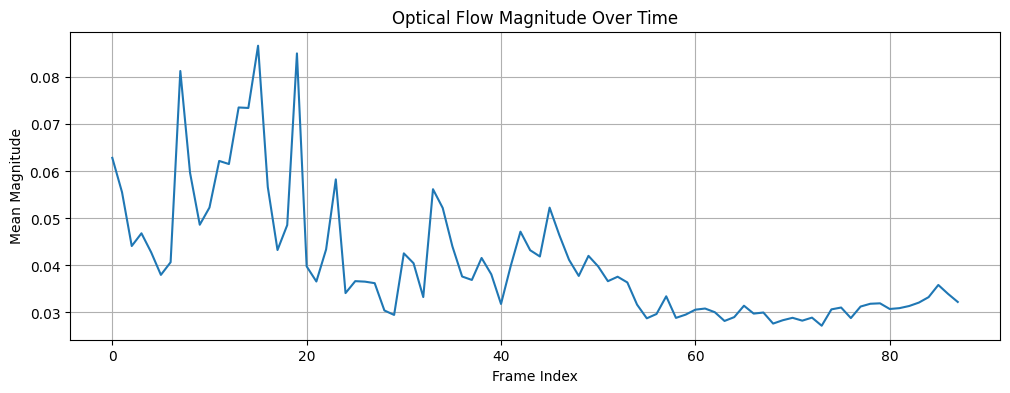

In [9]:
import matplotlib.pyplot as plt
import numpy as np

flow = np.load("../datasource/013_1_10_optical_flow.npy")
T = flow.shape[0]

# Formula to compute magnitude over optical flow =  sqrt(dx² + dy²)
mag = np.sqrt(flow[...,0]**2 + flow[...,1]**2)

plt.figure(figsize=(12,4))
plt.plot([mag[t].mean() for t in range(T)])
plt.title("Optical Flow Magnitude Over Time")
plt.xlabel("Frame Index")
plt.ylabel("Mean Magnitude")
plt.grid(True)
plt.show()


In [31]:
import os
import numpy as np
import pandas as pd
import torch
from torch.utils.data import Dataset
from pathlib import Path
from typing import List, Tuple, Dict

class AttentionApexDataset(Dataset):
    def __init__(self, root_dir: str, annotation_path: str, sigma: float = 4.0):
        super().__init__()
        self.root = Path(root_dir)
        self.annotation_path = Path(annotation_path)
        self.sigma = sigma 
        
        if not self.annotation_path.exists():
            raise FileNotFoundError(f"Annotation file not found: {self.annotation_path}")
        
        self.annotations = pd.read_csv(self.annotation_path)
        self.samples: List[Dict] = []
        
        valid_episodes = set(self.annotations['episode'].astype(str).values)
        
        for f in os.listdir(self.root):
            if f.endswith(".npy"):
                ep_id = f.replace("_optical_flow.npy", "").replace(".npy", "")
                if ep_id in valid_episodes:
                    self.samples.append({
                        "episode": ep_id,
                        "flow_path": self.root / f
                    })

    def __len__(self) -> int:
        return len(self.samples)
    
    def __getitem__(self, index: int) -> Tuple[torch.Tensor, torch.Tensor, int]:
        item = self.samples[index]
        flow = np.load(item["flow_path"])
        flow = np.transpose(flow, (0, 3, 1, 2))
        
        flow = (flow - flow.mean()) / (flow.std() + 1e-6)
        flow_tensor = torch.from_numpy(flow).float()

        meta = self.annotations[self.annotations["episode"] == item["episode"]].iloc[0]
        apex_idx = int(meta["apex"])
        seq_len = flow_tensor.shape[0]

        if apex_idx >= seq_len:
            apex_idx = seq_len - 1

        x = np.arange(seq_len)
        gaussian = np.exp(-((x - apex_idx)**2) / (2 * self.sigma**2))
        
        gaussian = gaussian / (gaussian.sum() + 1e-6)
        
        target_tensor = torch.from_numpy(gaussian).float()

        return flow_tensor, target_tensor, apex_idx

def collate_variable_length(batch: List[Tuple[torch.Tensor, torch.Tensor, int]]) -> Tuple[torch.Tensor, torch.Tensor, torch.Tensor, torch.Tensor]:
    flows_list, targets_list, apex_list = zip(*batch)
    max_len = max([f.shape[0] for f in flows_list])
    
    B = len(batch)
    C, H, W = flows_list[0].shape[1:]
    
    padded_flows = torch.zeros((B, max_len, C, H, W))
    padded_targets = torch.zeros((B, max_len))
    mask = torch.zeros((B, max_len), dtype=torch.bool)
    
    for i, (f, t) in enumerate(zip(flows_list, targets_list)):
        length = f.shape[0]
        padded_flows[i, :length] = f
        padded_targets[i, :length] = t
        mask[i, :length] = True
        
    apex_tensor = torch.tensor(apex_list, dtype=torch.long)
    
    return padded_flows, padded_targets, mask, apex_tensor

In [23]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from typing import Optional

class ConvEncoder(nn.Module):
    def __init__(self):
        super().__init__()
        self.enc = nn.Sequential(
            nn.Conv2d(2, 16, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(16, 32, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(32, 64, 3, padding=1),
            nn.ReLU(),
            nn.AdaptiveAvgPool2d((1,1))
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = self.enc(x)
        return x.view(x.size(0), -1)

class TemporalBiLSTM(nn.Module):
    def __init__(self, input_size: int = 64, hidden_size: int = 128):
        super().__init__()
        self.lstm = nn.LSTM(input_size=input_size,
                            hidden_size=hidden_size,
                            num_layers=1,
                            batch_first=True,
                            bidirectional=True)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        out, _ = self.lstm(x)
        return out

class TemporalAttention(nn.Module):
    def __init__(self, input_dim: int = 256):
        super().__init__()
        self.attn = nn.Linear(input_dim, 1)

    def forward(self, x: torch.Tensor, mask: Optional[torch.Tensor] = None) -> torch.Tensor:
        scores = self.attn(x).squeeze(-1)
        
        if mask is not None:
            scores = scores.masked_fill(~mask, float("-inf"))
            
        return F.log_softmax(scores, dim=1)

In [24]:
import torch
import torch.nn as nn
from typing import Optional


class ApexSpotter(nn.Module):
    def __init__(self):
        super().__init__()
        self.cnn = ConvEncoder()
        self.lstm = TemporalBiLSTM()
        self.att = TemporalAttention()

    def forward(self, flows: torch.Tensor, mask: Optional[torch.Tensor] = None) -> torch.Tensor:
        B, T, C, H, W = flows.shape

        flows_reshaped = flows.view(B * T, C, H, W)
        feats = self.cnn(flows_reshaped)
        feats = feats.view(B, T, -1)

        lstm_out = self.lstm(feats)
        log_probs = self.att(lstm_out, mask)

        return log_probs

In [32]:
import os
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, random_split
from tqdm import tqdm
from typing import Tuple


def train_one_epoch(model: nn.Module, loader: DataLoader, optimizer: torch.optim.Optimizer, criterion: nn.Module, device: torch.device) -> Tuple[float, float]:
    model.train()
    running_loss = 0.0
    total_mae = 0.0
    total_samples = 0

    pbar = tqdm(loader, desc="Training")

    for flows, targets, mask, real_apex in pbar:
        flows = flows.to(device)
        targets = targets.to(device)
        mask = mask.to(device)

        optimizer.zero_grad()

        log_probs = model(flows, mask)
        loss = criterion(log_probs, targets)

        loss.backward()
        
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        
        optimizer.step()

        running_loss += loss.item()

        pred_apex = log_probs.argmax(dim=1).cpu()
        mae = torch.abs(pred_apex - real_apex).float().sum().item()
        
        total_mae += mae
        total_samples += flows.size(0)

        pbar.set_postfix({"loss": loss.item()})
    
    if total_samples > 0:
        epoch_loss = running_loss / len(loader)
        epoch_mae = total_mae / total_samples
    else:
        epoch_loss = 0.0
        epoch_mae = 0.0

    return epoch_loss, epoch_mae


def validate(model: nn.Module, loader: DataLoader, criterion: nn.Module, device: torch.device) -> Tuple[float, float]:
    model.eval()
    running_loss = 0.0
    total_mae = 0.0
    total_samples = 0

    with torch.no_grad():
        for flows, targets, mask, real_apex in loader:
            flows = flows.to(device)
            targets = targets.to(device)
            mask = mask.to(device)

            log_probs = model(flows, mask)
            loss = criterion(log_probs, targets)

            running_loss += loss.item()
            
            pred_apex = log_probs.argmax(dim=1).cpu()
            mae = torch.abs(pred_apex - real_apex).float().sum().item()
            
            total_mae += mae
            total_samples += flows.size(0)

    epoch_loss = running_loss / len(loader)
    epoch_mae = total_mae / total_samples
    
    return epoch_loss, epoch_mae

def main():
    FLOW_DIR = "../datasource"
    ANNOTATION_PATH = "../datasource/annotations.csv"

    if not os.path.exists(FLOW_DIR) or not os.path.exists(ANNOTATION_PATH):
        print("Dataset path not found.")
        return

    dataset = AttentionApexDataset(root_dir=FLOW_DIR, annotation_path=ANNOTATION_PATH, sigma=4.0)
    
    if len(dataset) == 0:
        print("Dataset empty.")
        return

    train_size = int(0.8 * len(dataset))
    val_size = len(dataset) - train_size
    
    train_dataset, val_dataset = random_split(dataset, [train_size, val_size])

    train_loader = DataLoader(train_dataset, batch_size=4, shuffle=True, collate_fn=collate_variable_length)
    val_loader = DataLoader(val_dataset, batch_size=4, shuffle=False, collate_fn=collate_variable_length)

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model = ApexSpotter().to(device)
    
    criterion = nn.KLDivLoss(reduction="batchmean")
    
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)

    NUM_EPOCHS = 10
    for epoch in range(NUM_EPOCHS):
        print(f"\nEpoch {epoch+1}/{NUM_EPOCHS}")
        train_loss, train_mae = train_one_epoch(model, train_loader, optimizer, criterion, device)
        val_loss, val_mae = validate(model, val_loader, criterion, device)

        print(f"Train Loss: {train_loss:.6f} | Train MAE: {train_mae:.2f} frames")
        print(f"Val Loss:   {val_loss:.6f} | Val MAE:   {val_mae:.2f} frames")
        
        torch.save(model.state_dict(), f"../.local/pre-trained/best-{CURRENT_IDENTIFIER}.pth")


if __name__ == "__main__":
    main()


Epoch 1/10


Training: 100%|██████████| 32/32 [02:28<00:00,  4.65s/it, loss=nan]


Train Loss: nan | Train MAE: 19.72 frames
Val Loss:   nan | Val MAE:   17.47 frames

Epoch 2/10


Training: 100%|██████████| 32/32 [02:09<00:00,  4.05s/it, loss=nan]


Train Loss: nan | Train MAE: 17.86 frames
Val Loss:   nan | Val MAE:   16.09 frames

Epoch 3/10


...

Train Loss: nan | Train MAE: 9.13 frames
Val Loss:   nan | Val MAE:   14.41 frames

Epoch 9/10


Training: 100%|██████████| 32/32 [02:03<00:00,  3.86s/it, loss=nan]


Train Loss: nan | Train MAE: 9.75 frames
Val Loss:   nan | Val MAE:   16.59 frames

Epoch 10/10


Training: 100%|██████████| 32/32 [02:03<00:00,  3.86s/it, loss=nan]


Train Loss: nan | Train MAE: 9.39 frames
Val Loss:   nan | Val MAE:   15.59 frames


In [36]:
import cv2
import time
import numpy as np
import torch
import matplotlib.pyplot as plt
from typing import List, Tuple, Optional


class ApexInference:
    def __init__(self, model_path: str, device: Optional[torch.device] = None):
        self.device = device or torch.device("cuda" if torch.cuda.is_available() else "cpu")
        self.tvl1 = TVL1OpticalFlow()

        self.model = ApexSpotter().to(self.device)
        self.model.load_state_dict(torch.load(model_path, map_location=self.device))
        self.model.eval()

    def _process_frames(self, frames: List[np.ndarray]) -> torch.Tensor:
        if len(frames) < 2: return None
        
        gray_frames = [cv2.cvtColor(f, cv2.COLOR_BGR2GRAY) for f in frames]
        flows = []
        
        for i in range(1, len(gray_frames)):
            prev, curr = gray_frames[i-1], gray_frames[i]
            flow = self.tvl1.compute_between(prev, curr)
            flow_resized = self.tvl1.resize_flow(flow, target_size=(224, 224))
            flows.append(flow_resized)
            
        flows_np = np.stack(flows)
        flows_np = np.transpose(flows_np, (0, 3, 1, 2))
        
        flows_np = np.nan_to_num(flows_np)
        std = flows_np.std()
        if std < 1e-6: std = 1e-6
        flows_np = (flows_np - flows_np.mean()) / std
        
        return torch.from_numpy(flows_np).float()

    def predict(self, frames: List[np.ndarray]) -> Tuple[int, np.ndarray]:
        tensor_flow = self._process_frames(frames)
        if tensor_flow is None: return 0, np.array([])

        input_flow = tensor_flow.unsqueeze(0).to(self.device)
        
        with torch.no_grad():
            log_probs = self.model(input_flow)
            
            curve = torch.exp(log_probs).squeeze(0).cpu().numpy()
            
        predicted_apex_idx = int(curve.argmax())
        
        return predicted_apex_idx, curve

Press SPACE to start recording from webcam...
Processing frames for apex prediction...
Predicted apex frame index: 19


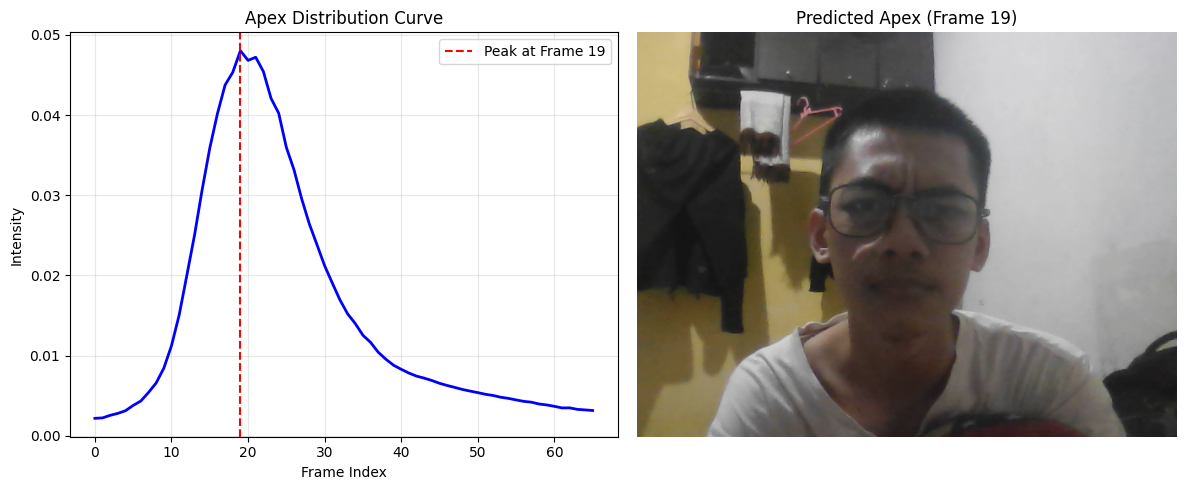

In [38]:
def capture_webcam(duration=3):
    cap = cv2.VideoCapture(0)
    
    while True:
        _, frame = cap.read()
        cv2.imshow("Preview", cv2.flip(frame, 1))
        if cv2.waitKey(1) == 32: break # Spacebar
    
    frames = []
    start = time.time()
    
    while time.time() - start < duration:
        ret, frame = cap.read()
        if ret:
            frames.append(cv2.flip(frame, 1))
            cv2.imshow("Preview", cv2.flip(frame, 1))
            cv2.waitKey(1)
    
    cap.release()
    cv2.destroyAllWindows()
    return frames

def show_result(frames, idx, curve):
    if idx < len(frames):
        img = frames[idx]
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    else:
        img = np.zeros((224,224,3), dtype=np.uint8)
    
    _, ax = plt.subplots(1, 2, figsize=(12, 5))
    
    ax[0].plot(curve, color='blue', linewidth=2)
    ax[0].axvline(x=idx, color='red', linestyle='--', label=f'Peak at Frame {idx}')
    ax[0].set_title("Apex Distribution Curve")
    ax[0].set_xlabel("Frame Index")
    ax[0].set_ylabel("Intensity")
    ax[0].legend()
    ax[0].grid(True, alpha=0.3)
    
    ax[1].imshow(img)
    ax[1].set_title(f"Predicted Apex (Frame {idx})")
    ax[1].axis("off")
    
    plt.tight_layout()
    plt.show()

if __name__ == "__main__":
    MODEL_PATH = f"../.local/pre-trained/best-{CURRENT_IDENTIFIER}.pth"
    
    try:
        inference = ApexInference(MODEL_PATH)
        
        print("Press SPACE to start recording from webcam...")
        frames = capture_webcam(duration=4)
        
        if len(frames) > 10:
            print("Processing frames for apex prediction...")
            apex_idx, distribution_curve = inference.predict(frames)

            print(f"Predicted apex frame index: {apex_idx}")
            show_result(frames, apex_idx, distribution_curve)
        else:
            print("Video too short.")
            
    except Exception as e:
        print(f"Error: {e}")